# Motif filtering

Inspect every `motif_hits.csv` found recursively under a PVL output root:

1. distribution of all log-likelihood scores
2. distribution of scores per classification
3. spectrograms of every hit above a score threshold, grouped by motif (`submodel_id`, shared across recordings)

Each hit's recording is the name of the folder containing its `motif_hits.csv` (`<folder name>.wav` / `.m4a`), searched recursively under `AUDIO_ROOT`.

In [1]:
# ---- configuration ----
# root searched recursively for motif_hits.csv; each csv's folder name is its recording name
PVL_PATH   = '/Users/dkohlsdorf/Documents/pvl_merge/motif_extend_find_20_states_fixed/'
AUDIO_ROOT = '/Users/dkohlsdorf/Documents/audio/wdp_data_at_google'   # searched recursively for .wav / .m4a

SCORE_COL  = 'mean_llr_score'   # or 'mean_emission_score' / 'mean_noise_score'
THRESHOLDS = {                   # keep hits with SCORE_COL >= threshold of their classification
    'WHISTLE': 30.0,
    'BURST':   10.0,
    'ECHO':    10.0,
    'NOISE':   15.0,
}
DEFAULT_THRESHOLD = 5.0          # for classifications not listed above
CLASSES    = None                # e.g. ['WHISTLE', 'BURST'] to restrict; None = all

MAX_EXAMPLES_PER_MOTIF = None    # cap per motif grid (highest-scoring first); None = all
N_COLS     = 5
PAD_S      = 0.1                 # context added before/after each hit
N_FFT      = 512
HOP        = 128
FMAX_HZ    = None                # e.g. 24000 to crop the spectrogram; None = Nyquist

In [2]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

%matplotlib inline

## Load hits and locate audio

In [3]:
def find_files(root, name):
    return sorted(glob.glob(os.path.join(glob.escape(root), '**', name), recursive=True))


# recording name -> audio path (wav preferred over m4a)
audio_index = {}
for ext in ('m4a', 'wav'):
    for p in find_files(AUDIO_ROOT, '*.' + ext):
        audio_index[os.path.splitext(os.path.basename(p))[0]] = p

frames = []
for csv_path in find_files(PVL_PATH, 'motif_hits.csv'):
    df = pd.read_csv(csv_path)
    df['recording'] = os.path.basename(os.path.dirname(csv_path))
    frames.append(df)
hits = pd.concat(frames, ignore_index=True)
hits['audio_path'] = hits.recording.map(audio_index)
hits['threshold'] = hits.classification.map(THRESHOLDS).fillna(DEFAULT_THRESHOLD)
hits['passes'] = hits[SCORE_COL] >= hits.threshold
classes = sorted(hits.classification.dropna().unique())

per_rec = hits.groupby('recording').agg(n_hits=('hit_id', 'size'), audio_path=('audio_path', 'first'))
missing = per_rec.index[per_rec.audio_path.isna()].tolist()
print(f'{len(hits)} hits from {len(per_rec)} recordings, {hits.submodel_id.nunique()} motifs')
if missing:
    print(f'WARNING: no audio under {AUDIO_ROOT} for: {missing}')
per_rec

17254 hits from 29 recordings, 350 motifs


,n_hits,audio_path
recording,,
05222401_SKATE_TASCAM,342,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...
05232401_SKATE_TASCAM,1025,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...
05242301_SKATE,320,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...
05262401_SKATE_TASCAM,468,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...
05272401_SKATE_TASCAM,902,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...
06052401_SKATE_TASCAM (jump 1),465,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...
06052401_SKATE_TASCAM (jump 2),515,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...
07032401_SKATE_TASCAM,829,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...
07092501_EAGLE_TASCAM (jump 1),406,/Users/dkohlsdorf/Documents/audio/wdp_data_at_...


In [4]:
(hits.groupby('classification')
     .agg(n=('passes', 'size'), threshold=('threshold', 'first'), n_pass=('passes', 'sum'))
     .assign(frac_pass=lambda d: d.n_pass / d.n))

,n,threshold,n_pass,frac_pass
classification,,,,
BURST,976,10.0,313,0.320697
ECHO,4455,10.0,2637,0.591919
NOISE,8939,15.0,189,0.021143
WHISTLE,2884,30.0,791,0.274272


## Distribution of all scores

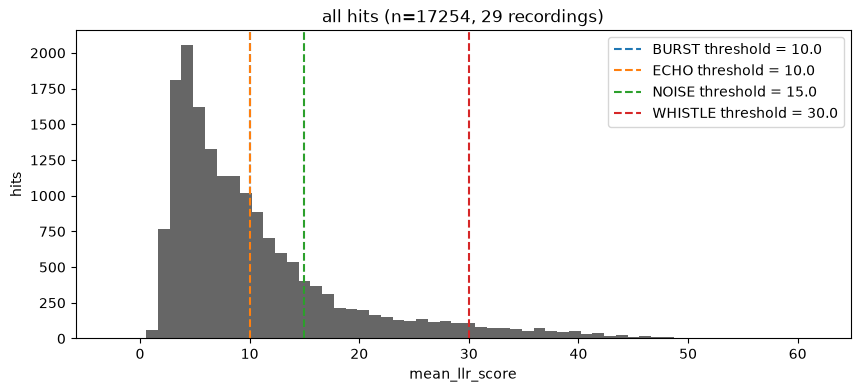

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hits[SCORE_COL], bins=60, color='0.4')
for i, c in enumerate(classes):
    t = hits.loc[hits.classification == c, 'threshold'].iloc[0]
    ax.axvline(t, color=f'C{i}', ls='--', label=f'{c} threshold = {t}')
ax.set_xlabel(SCORE_COL)
ax.set_ylabel('hits')
ax.set_title(f'all hits (n={len(hits)}, {hits.recording.nunique()} recordings)')
ax.legend()
plt.show()

## Distribution of scores per classification

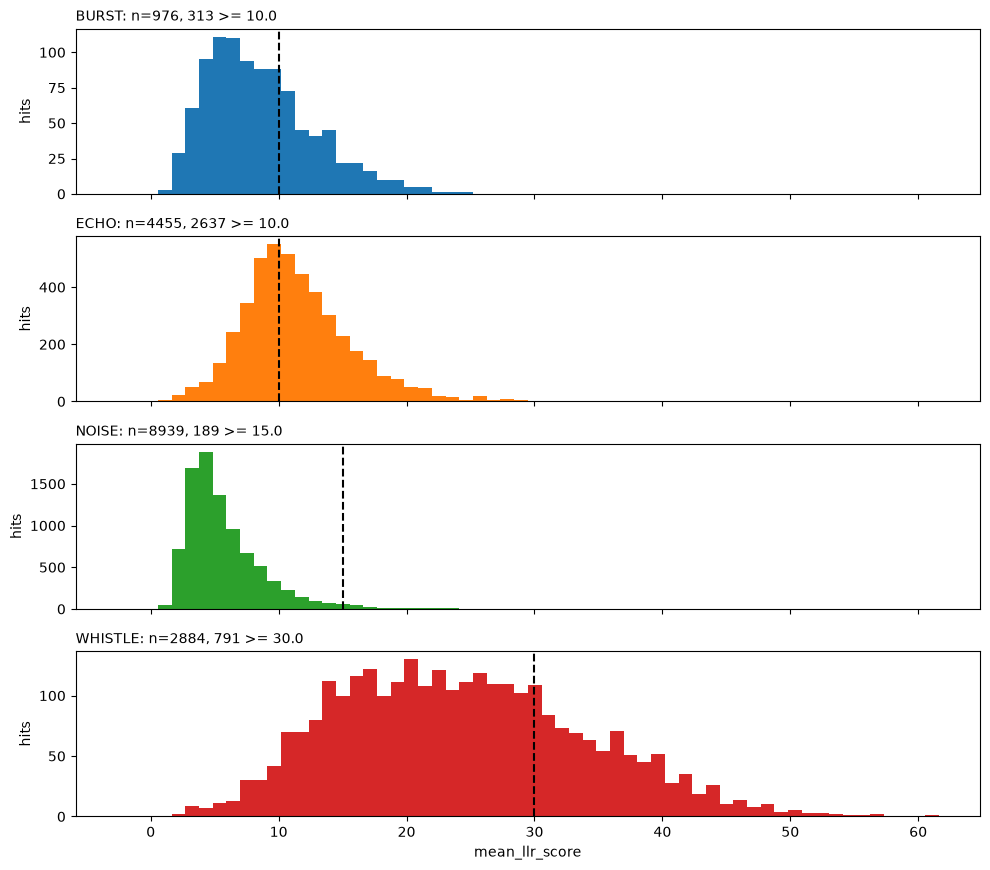

/var/folders/m3/mdprcgf577gfkvcc9s6qdt8h0000gn/T/ipykernel_26637/2521913496.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([hits.loc[hits.classification == c, SCORE_COL] for c in classes], vert=False)


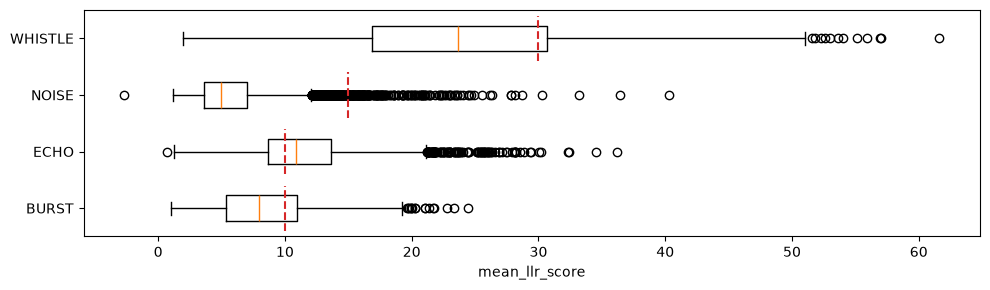

In [6]:
bins = np.histogram_bin_edges(hits[SCORE_COL], bins=60)

fig, axes = plt.subplots(len(classes), 1, figsize=(10, 2.2 * len(classes)), sharex=True)
axes = np.atleast_1d(axes)
for i, (ax, c) in enumerate(zip(axes, classes)):
    h = hits[hits.classification == c]
    t = h.threshold.iloc[0]
    ax.hist(h[SCORE_COL], bins=bins, color=f'C{i}')
    ax.axvline(t, color='k', ls='--')
    ax.set_title(f'{c}: n={len(h)}, {h.passes.sum()} >= {t}', loc='left', fontsize=10)
    ax.set_ylabel('hits')
axes[-1].set_xlabel(SCORE_COL)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot([hits.loc[hits.classification == c, SCORE_COL] for c in classes], vert=False)
ax.set_yticks(range(1, len(classes) + 1), classes)
for i, c in enumerate(classes, start=1):
    t = hits.loc[hits.classification == c, 'threshold'].iloc[0]
    ax.plot([t, t], [i - 0.4, i + 0.4], color='C3', ls='--')
ax.set_xlabel(SCORE_COL)
plt.tight_layout()
plt.show()

## Apply threshold

In [7]:
kept = hits[hits.passes].copy()
if CLASSES is not None:
    kept = kept[kept.classification.isin(CLASSES)]
kept['duration_s'] = kept.stop_time_s - kept.start_time_s
kept = kept.sort_values(['submodel_id', SCORE_COL], ascending=[True, False])

summary = (kept.groupby('submodel_id')
               .agg(n=(SCORE_COL, 'size'),
                    score_mean=(SCORE_COL, 'mean'),
                    duration_mean_s=('duration_s', 'mean'),
                    n_recordings=('recording', 'nunique'),
                    classes=('classification', lambda s: s.value_counts().to_dict()))
               .sort_values('n', ascending=False))
print(f'{len(kept)} / {len(hits)} hits kept across {len(summary)} motifs')
summary

3930 / 17254 hits kept across 282 motifs


,n,score_mean,duration_mean_s,n_recordings,classes
submodel_id,,,,,
428,96,12.040950,1.194255,16,"{'ECHO': 95, 'BURST': 1}"
598,94,11.682905,2.000868,17,{'ECHO': 94}
522,92,13.513487,2.000828,19,{'ECHO': 92}
544,92,36.138540,0.845509,18,{'WHISTLE': 92}
602,82,12.230118,1.100824,16,{'ECHO': 82}
...,...,...,...,...,...
299,1,19.123664,0.174150,1,{'ECHO': 1}
288,1,38.893383,1.044898,1,{'WHISTLE': 1}
265,1,12.761667,0.290249,1,{'ECHO': 1}


## Examples per motif

In [8]:
def load_clip(path, start_s, stop_s):
    # wav: seek directly; m4a: decode the window via ffmpeg (librosa/audioread)
    if path.lower().endswith('.wav'):
        sr = sf.info(path).samplerate
        a = max(0, int((start_s - PAD_S) * sr))
        x, sr = sf.read(path, start=a, stop=int((stop_s + PAD_S) * sr), always_2d=True)
        x = x.mean(axis=1)
    else:
        a_s = max(0.0, start_s - PAD_S)
        x, sr = librosa.load(path, sr=None, mono=True, offset=a_s, duration=stop_s + PAD_S - a_s)
        a = int(a_s * sr)
    return x, sr, a / sr


def spec_db(path, start_s, stop_s):
    x, sr, t0 = load_clip(path, start_s, stop_s)
    S = np.abs(librosa.stft(x.astype(np.float32), n_fft=N_FFT, hop_length=HOP))
    return librosa.amplitude_to_db(S, ref=np.max), sr, t0, t0 + len(x) / sr

In [9]:
plot_hits = kept.dropna(subset=['audio_path'])
cls_color = {c: f'C{i}' for i, c in enumerate(classes)}

for motif, g in plot_hits.groupby('submodel_id'):
    total = len(g)
    if MAX_EXAMPLES_PER_MOTIF is not None:
        g = g.head(MAX_EXAMPLES_PER_MOTIF)
    n = len(g)
    if n < 2:
        continue
    n_rows = int(np.ceil(n / N_COLS))
    fig, axes = plt.subplots(n_rows, N_COLS, figsize=(3.2 * N_COLS, 2.6 * n_rows), squeeze=False)
    for ax, (_, h) in zip(axes.flat, g.iterrows()):
        S, sr, t0, t1 = spec_db(h.audio_path, h.start_time_s, h.stop_time_s)
        ax.imshow(S, origin='lower', aspect='auto', cmap='magma', vmin=-80, vmax=0, extent=[t0, t1, 0, sr / 2])
        ax.axvline(h.start_time_s, color='w', lw=0.8, ls=':')
        ax.axvline(h.stop_time_s, color='w', lw=0.8, ls=':')
        ax.set_ylim(0, FMAX_HZ or sr / 2)
        ax.set_title(f'{h.recording[:22]} #{h.hit_id} {h.classification} {h[SCORE_COL]:.2f}',
                     fontsize=7, color=cls_color.get(h.classification, 'k'))
        ax.tick_params(labelsize=6)
    for ax in axes.flat[n:]:
        ax.axis('off')
    fig.suptitle(f'motif {motif}: showing {n} of {total} hits above their classification threshold ({SCORE_COL})', y=1.0)
    plt.tight_layout()
    plt.savefig(f'images/{motif}.png')
    plt.close()
    #plt.show()

/var/folders/m3/mdprcgf577gfkvcc9s6qdt8h0000gn/T/ipykernel_26637/1699054729.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  x, sr = librosa.load(path, sr=None, mono=True, offset=a_s, duration=stop_s + PAD_S - a_s)
/opt/anaconda3/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
